
# Nevermore pipeline launcher

Run the cached Nevermore pipeline from a single notebook cell. Edit the config path or `up_to` stage as needed.


In [ ]:
import sys
from pathlib import Path
repo_root = Path.cwd()
if '__file__' in globals():
    repo_root = Path(__file__).resolve().parents[2]
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))


from nevermore.pipeline import NevermorePipeline, STAGE_ORDER

config_path = "nevermore/configs/default.yaml"  # change if you keep overrides elsewhere
up_to = "retrieval"  # choose from: ingest, features, optimization, retrieval, visualization, docking, admet, report

pipe = NevermorePipeline(config_path=config_path)
results = pipe.run(up_to=up_to)

for name, res in results.items():
    print(f"[{name}] {res.signature} -> {res.outputs}")


In [ ]:

# Inspect candidates (if retrieval ran)
import pandas as pd
from pathlib import Path
retrieval = results.get("retrieval")
if retrieval and retrieval.outputs:
    cand_path = Path(retrieval.outputs.get("candidates", ""))
    if cand_path.exists():
        display(pd.read_csv(cand_path).head())


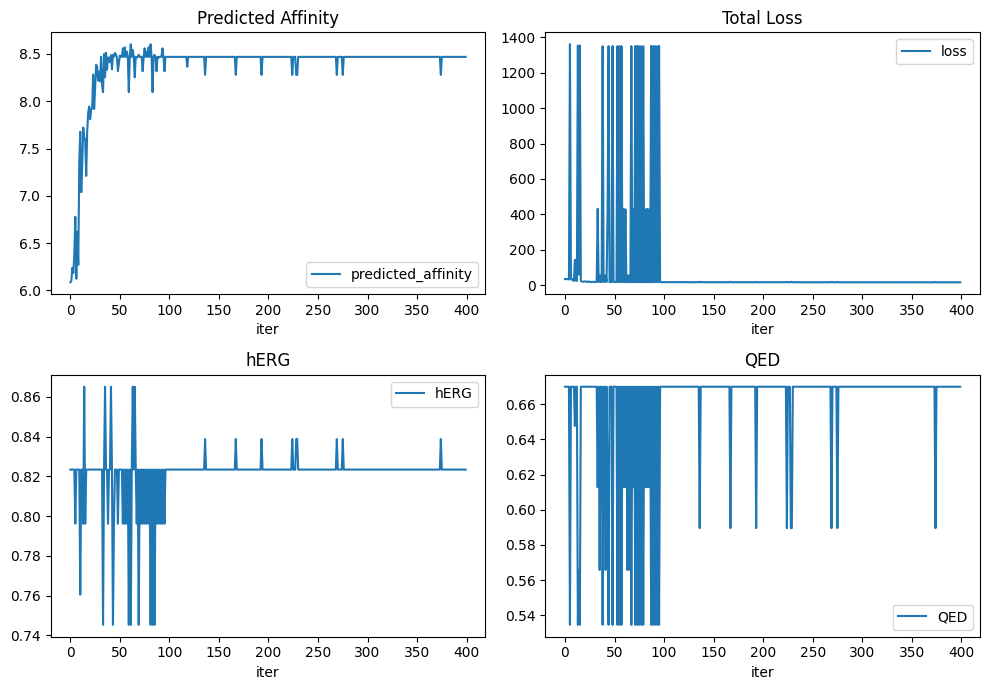

,iter,predicted_affinity,loss,admet_penalty,protein_delta_L1,ligand_delta_L1,ligand_counts,hERG,molecular_weight,QED
0,0,6.085999,35.184604,0.209191,0.0,0.0,"[2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...",0.823412,465.573,0.669917
1,1,6.104033,35.471612,0.209191,0.0,1.0,"[3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...",0.823412,465.573,0.669917
2,2,6.239107,33.897077,0.209191,0.0,1.0,"[2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...",0.823412,465.573,0.669917


,iter,predicted_affinity,loss,admet_penalty,protein_delta_L1,ligand_delta_L1,ligand_counts,hERG,molecular_weight,QED
397,397,8.468573,16.648593,0.209191,0.0,7.936845,"[2, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, ...",0.823412,465.573,0.669917
398,398,8.468573,16.669691,0.209191,0.0,7.979043,"[2, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, ...",0.823412,465.573,0.669917
399,399,8.468573,16.643451,0.209191,0.0,7.926562,"[2, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, ...",0.823412,465.573,0.669917


In [6]:
import json
import pandas as pd
import matplotlib.pyplot as plt


trace_path = "../../outputs/optimization/cdc21513e920/optimization_trace.csv"  # update signature
df = pd.read_csv(trace_path)

# Expand ADMET dict column into separate columns
def expand_admet(row):
    if pd.isna(row):
        return {}
    try:
        return json.loads(row)
    except Exception:
        return {}
admet_df = df["admet"].apply(expand_admet).apply(pd.Series)
df = pd.concat([df.drop(columns=["admet"]), admet_df], axis=1)

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.ravel()

df.plot(x="iter", y="predicted_affinity", ax=axes[0], title="Predicted Affinity")
df.plot(x="iter", y="loss", ax=axes[1], title="Total Loss")
if "hERG" in df: df.plot(x="iter", y="hERG", ax=axes[2], title="hERG")
if "QED" in df: df.plot(x="iter", y="QED", ax=axes[3], title="QED")

plt.tight_layout()
plt.show()

# Show first/last rows for quick comparison
display(df.head(3))
display(df.tail(3))
